# Exploratory Data Analysis (EDA)
Analisis pola sinyal suara kambing Etawa pada kondisi Normal dan Lapar berdasarkan dataset `.m4a`.


In [ ]:
import os
import imageio_ffmpeg
import audioread.ffdec

# Injeksi paksa FFmpeg agar librosa bisa membaca .m4a di Windows tanpa error
audioread.ffdec.COMMANDS = (imageio_ffmpeg.get_ffmpeg_exe(), )
ffmpeg_dir = os.path.dirname(imageio_ffmpeg.get_ffmpeg_exe())
if ffmpeg_dir not in os.environ["PATH"]:
    os.environ["PATH"] = ffmpeg_dir + os.pathsep + os.environ["PATH"]


## 1. Import Library


In [ ]:
import os
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks


## 2. Pemeriksaan Dataset
Mengecek ketersediaan jumlah file di folder `Rawdataset`.


In [ ]:
base_path = "../Rawdataset"

normal_dir = os.path.join(base_path, "normal")
lapar_dir = os.path.join(base_path, "lapar")

print("Jumlah file audio NORMAL :", len(os.listdir(normal_dir)))
print("Jumlah file audio LAPAR :", len(os.listdir(lapar_dir)))


Jumlah file audio NORMAL : 15
Jumlah file audio LAPAR : 17


## 3. Ekstraksi Data Audio (Normal)
Membaca setiap file m4a kondisi normal dan menyimpannya ke dalam dictionary memori.


In [ ]:
normal_path = "../Rawdataset/normal/"
normal_audio_data = {}
normal_sample_rates = {}

normal_files = [f for f in os.listdir(normal_path) if f.endswith('.m4a')]
for file in normal_files:
    file_path = os.path.join(normal_path, file)
    y_normal, sr_normal = librosa.load(file_path, sr=None)

    key = file.replace('.m4a', '')
    normal_audio_data[key] = y_normal
    normal_sample_rates[key] = sr_normal

    print(f"File              : {file}")
    print(f"Sample Rate       : {sr_normal} Hz")
    print(f"Total Samples     : {len(y_normal)}")
    print(f"Durasi Audio      : {len(y_normal)/sr_normal:.2f} detik")
    print("-"*40)


c:\Freelance\Kambing\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\Wahyu Kusuma\AppData\Local\Temp\ipykernel_19432\500882134.py:8: UserWarning: PySoundFile failed. Trying audioread instead.
  y_normal, sr_normal = librosa.load(file_path, sr=None)
c:\Freelance\Kambing\.venv\Lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


File              : normal 1.m4a
Sample Rate       : 48000 Hz
Total Samples     : 11965440
Durasi Audio      : 249.28 detik
----------------------------------------


C:\Users\Wahyu Kusuma\AppData\Local\Temp\ipykernel_19432\500882134.py:8: UserWarning: PySoundFile failed. Trying audioread instead.
  y_normal, sr_normal = librosa.load(file_path, sr=None)
c:\Freelance\Kambing\.venv\Lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


File              : normal 10.m4a
Sample Rate       : 48000 Hz
Total Samples     : 16575488
Durasi Audio      : 345.32 detik
----------------------------------------
File              : normal 11.m4a
Sample Rate       : 48000 Hz
Total Samples     : 14556160
Durasi Audio      : 303.25 detik
----------------------------------------
File              : normal 2.m4a
Sample Rate       : 48000 Hz
Total Samples     : 15285248
Durasi Audio      : 318.44 detik
----------------------------------------
File              : normal 3.m4a
Sample Rate       : 48000 Hz
Total Samples     : 13179904
Durasi Audio      : 274.58 detik
----------------------------------------
File              : normal 4.m4a
Sample Rate       : 48000 Hz
Total Samples     : 5719040
Durasi Audio      : 119.15 detik
----------------------------------------
File              : normal 5.m4a
Sample Rate       : 48000 Hz
Total Samples     : 15534080
Durasi Audio      : 323.63 detik
----------------------------------------
File     

## 4. Ekstraksi Data Audio (Lapar)
Membaca setiap file m4a kondisi lapar dan menyimpannya ke dalam dictionary memori.


In [ ]:
lapar_path = "../Rawdataset/lapar/"
lapar_audio_data = {}
lapar_sample_rates = {}

lapar_files = [f for f in os.listdir(lapar_path) if f.endswith('.m4a')]
for file in lapar_files:
    file_path = os.path.join(lapar_path, file)
    y_lapar, sr_lapar = librosa.load(file_path, sr=None)

    key = file.replace('.m4a', '')
    lapar_audio_data[key] = y_lapar
    lapar_sample_rates[key] = sr_lapar

    print(f"File              : {file}")
    print(f"Sample Rate       : {sr_lapar} Hz")
    print(f"Total Samples     : {len(y_lapar)}")
    print(f"Durasi Audio      : {len(y_lapar)/sr_lapar:.2f} detik")
    print("-"*40)


C:\Users\Wahyu Kusuma\AppData\Local\Temp\ipykernel_19432\2356656121.py:8: UserWarning: PySoundFile failed. Trying audioread instead.
  y_lapar, sr_lapar = librosa.load(file_path, sr=None)


File              : lapar 1.m4a
Sample Rate       : 48000 Hz
Total Samples     : 16053248
Durasi Audio      : 334.44 detik
----------------------------------------
File              : lapar 2.m4a
Sample Rate       : 48000 Hz
Total Samples     : 14058496
Durasi Audio      : 292.89 detik
----------------------------------------
File              : lapar 3.m4a
Sample Rate       : 48000 Hz
Total Samples     : 14869504
Durasi Audio      : 309.78 detik
----------------------------------------
File              : lapar 4.m4a
Sample Rate       : 48000 Hz
Total Samples     : 15450112
Durasi Audio      : 321.88 detik
----------------------------------------
File              : lapar 5.m4a
Sample Rate       : 48000 Hz
Total Samples     : 11052032
Durasi Audio      : 230.25 detik
----------------------------------------
File              : lapar 6.m4a
Sample Rate       : 48000 Hz
Total Samples     : 14863360
Durasi Audio      : 309.65 detik
----------------------------------------
File            

## 5. Visualisasi Waveform Keseluruhan
Plot seluruh sampel waveform secara vertikal untuk membandingkan karakteristik amplitudo suara dari masing-masing sampel Normal dan Lapar.


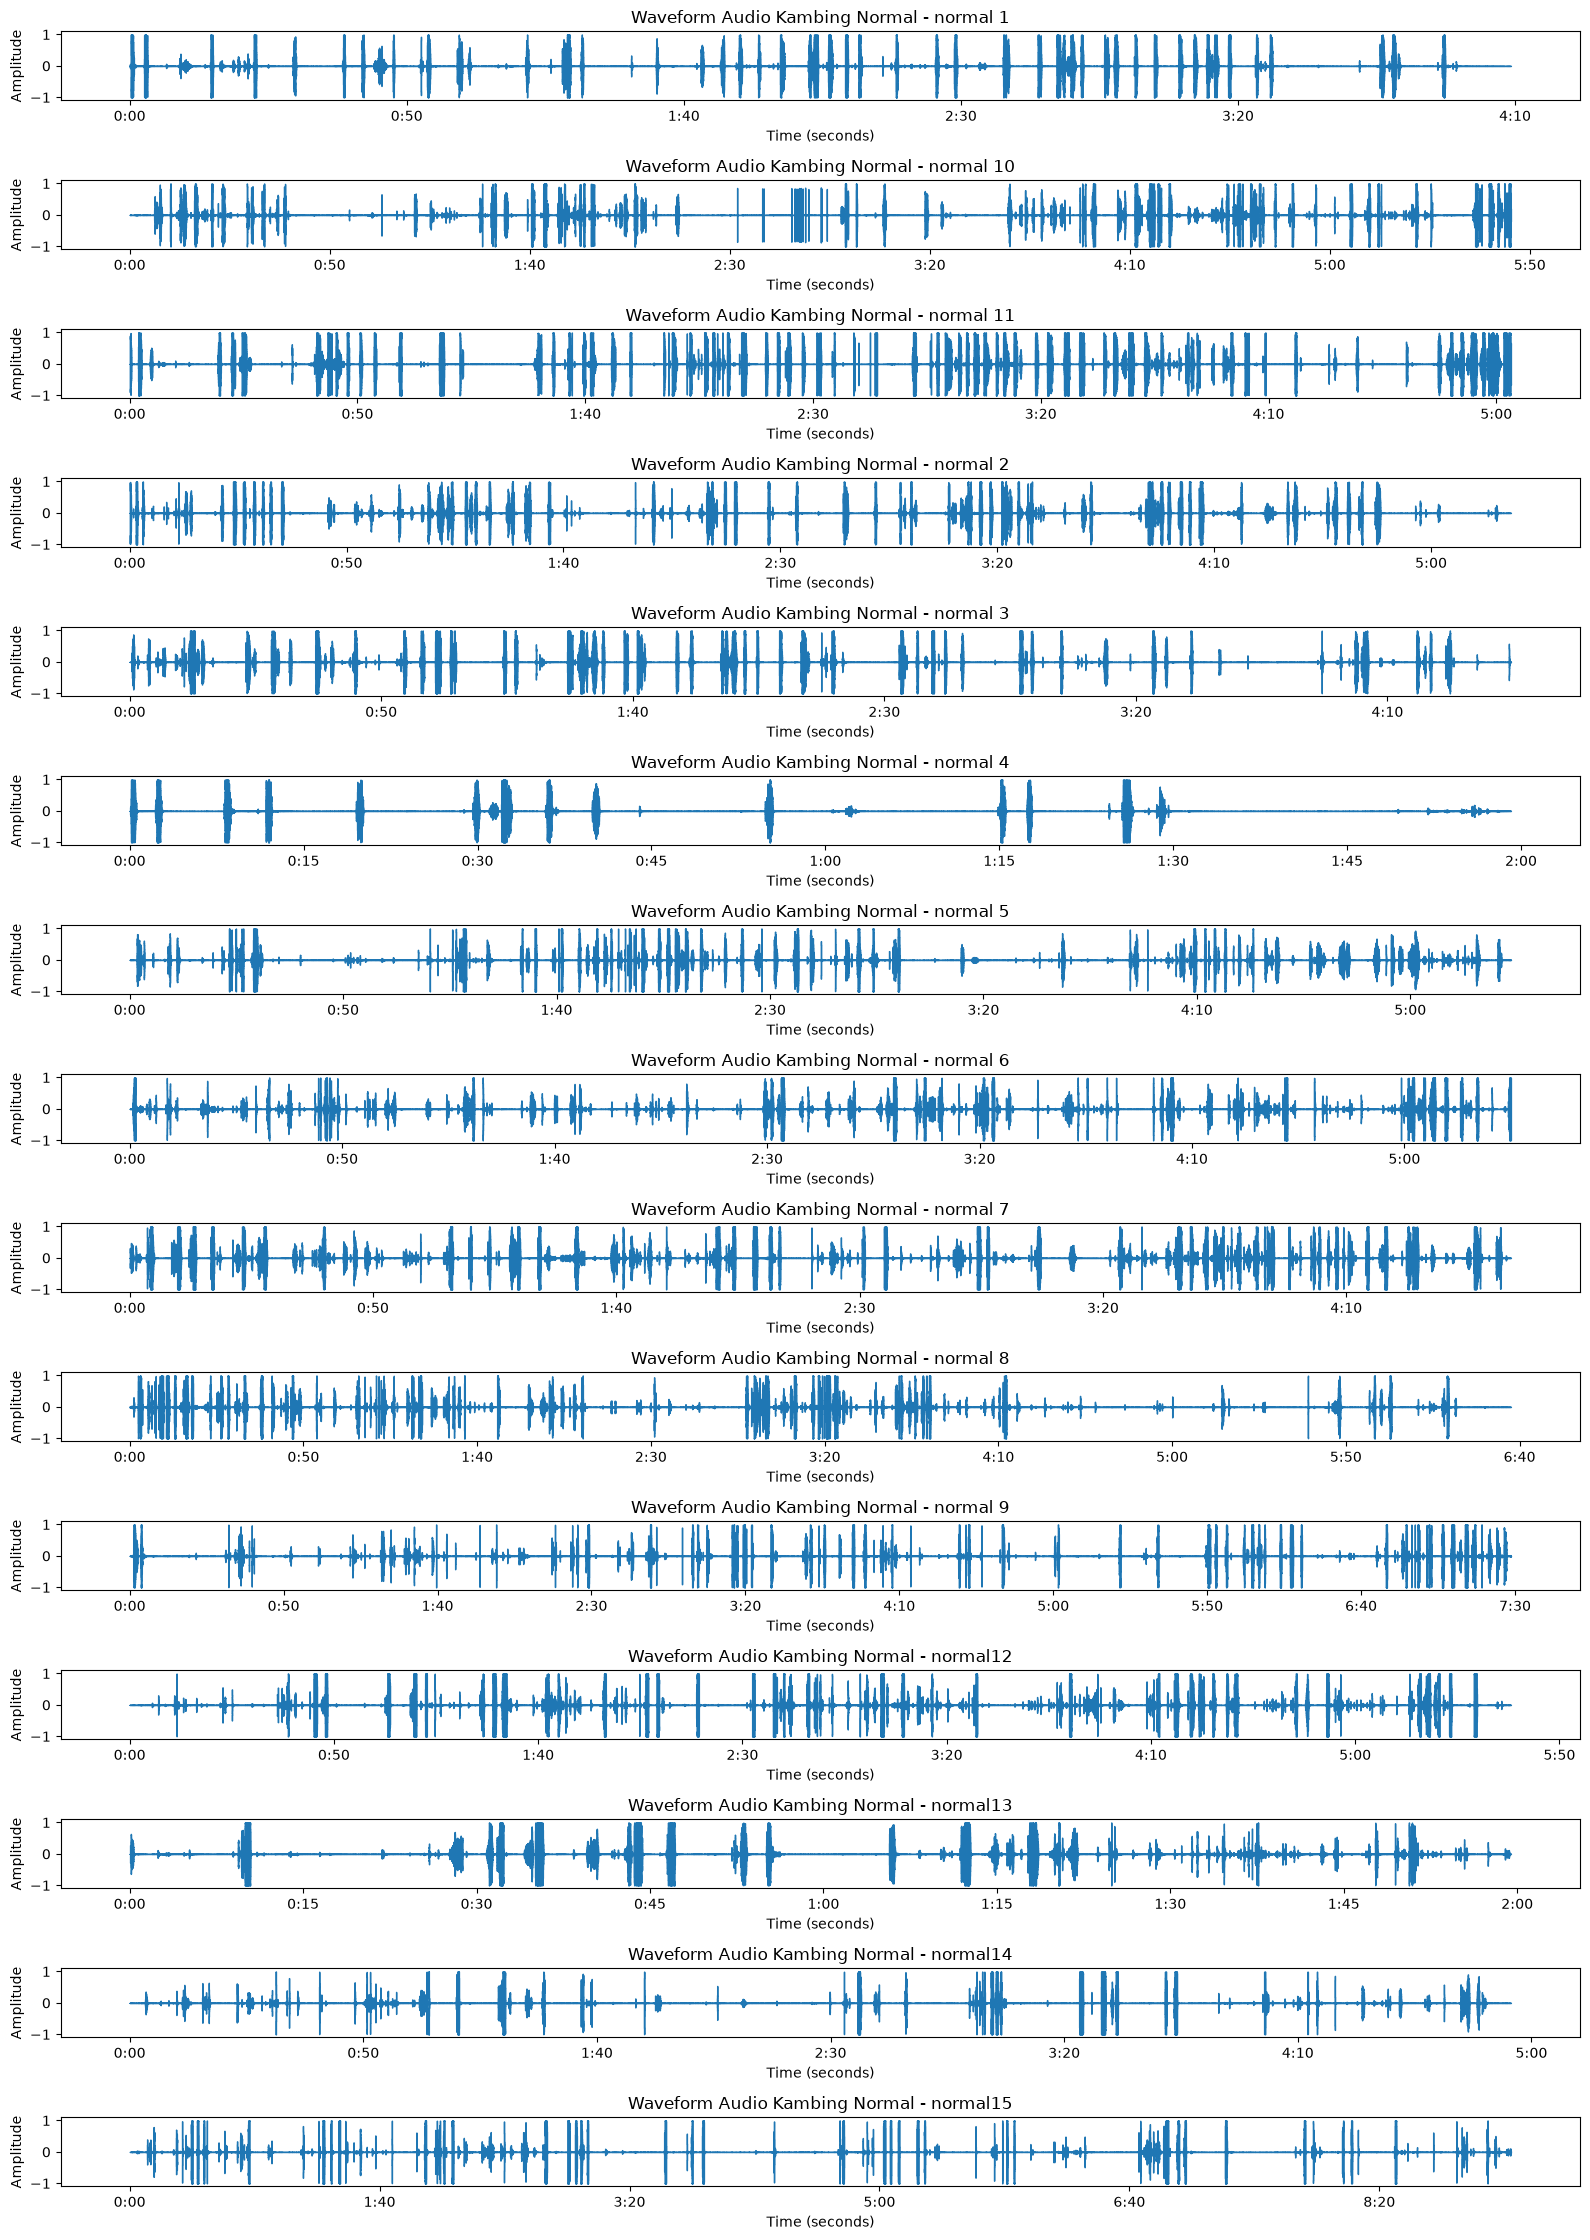

In [ ]:
n_normal = len(normal_audio_data)
plt.figure(figsize=(16, max(6, n_normal * 1.5)))

for idx, (key, y_normal) in enumerate(normal_audio_data.items(), start=1):
    sr_normal = normal_sample_rates[key]

    plt.subplot(n_normal, 1, idx)
    librosa.display.waveshow(y_normal, sr=sr_normal)
    plt.title(f"Waveform Audio Kambing Normal - {key}")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()


### Plot Spesifik (1 Sampel Normal)


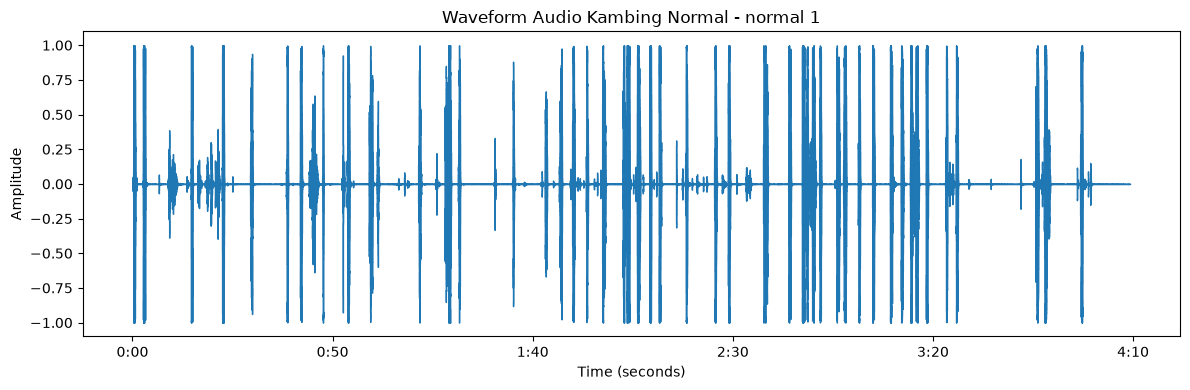

In [ ]:
key, y_normal = list(normal_audio_data.items())[0]
sr_normal = normal_sample_rates[key]

plt.figure(figsize=(12, 4))
librosa.display.waveshow(y_normal, sr=sr_normal)
plt.title(f"Waveform Audio Kambing Normal - {key}")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()


### Plot Spesifik Keseluruhan (Lapar)


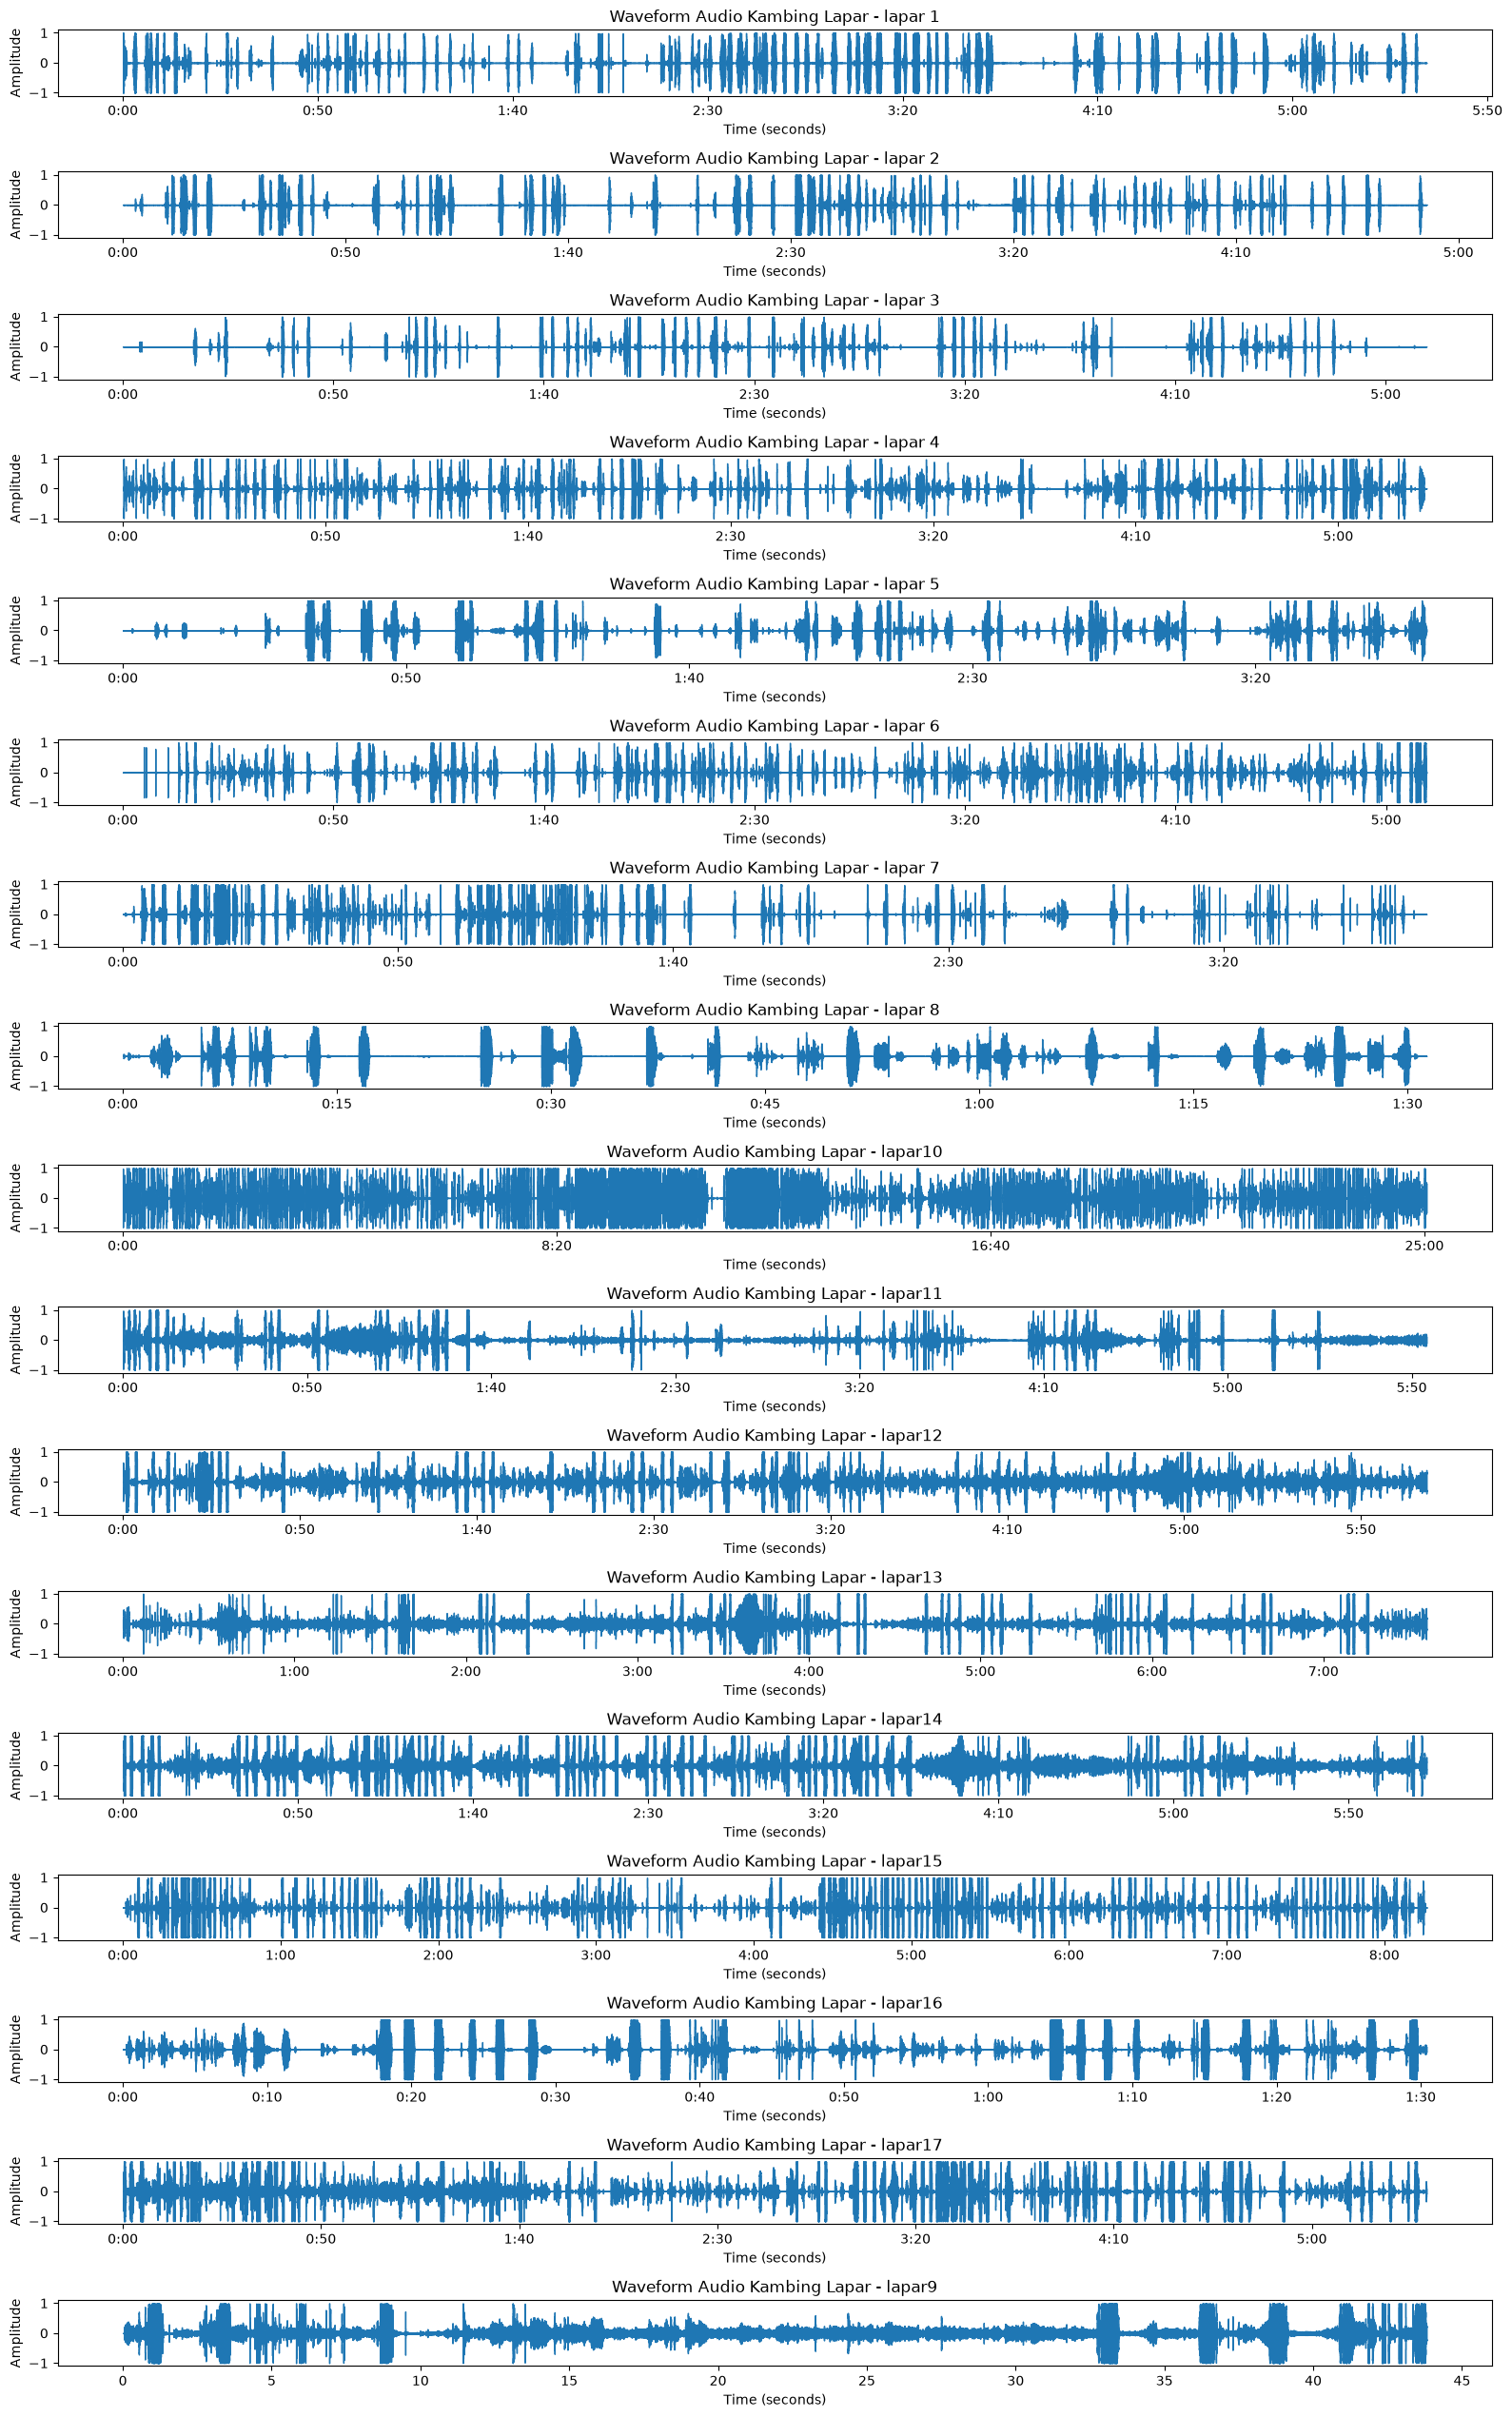

In [ ]:
n_lapar = len(lapar_audio_data)
plt.figure(figsize=(16, max(6, n_lapar * 1.5)))

for idx, (key, y_lapar) in enumerate(lapar_audio_data.items(), start=1):
    sr_lapar = lapar_sample_rates[key]

    plt.subplot(n_lapar, 1, idx)
    librosa.display.waveshow(y_lapar, sr=sr_lapar)
    plt.title(f"Waveform Audio Kambing Lapar - {key}")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()


## 6. Analisis RMS Energy
Menghitung *Root Mean Square* (RMS) untuk mengukur total energi atau tingkat kekerasan (intensitas) suara pada setiap *frame*.


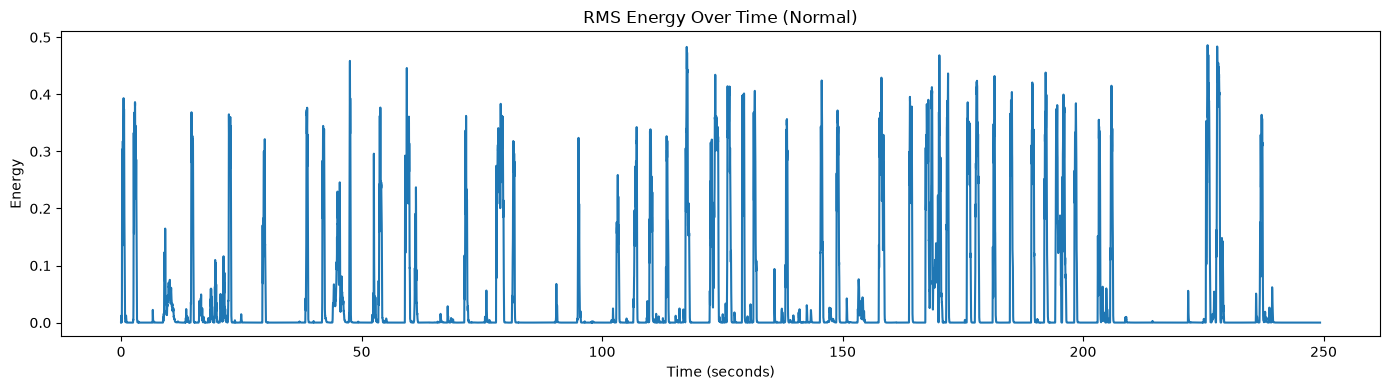

In [ ]:
hop_length = 512
frame_length = 2048

rms = librosa.feature.rms(
    y=y_normal,
    frame_length=frame_length,
    hop_length=hop_length
)[0]

times = librosa.frames_to_time(range(len(rms)), sr=sr_normal, hop_length=hop_length)

plt.figure(figsize=(14,4))
plt.plot(times, rms)
plt.title("RMS Energy Over Time (Normal)")
plt.xlabel("Time (seconds)")
plt.ylabel("Energy")
plt.tight_layout()
plt.show()


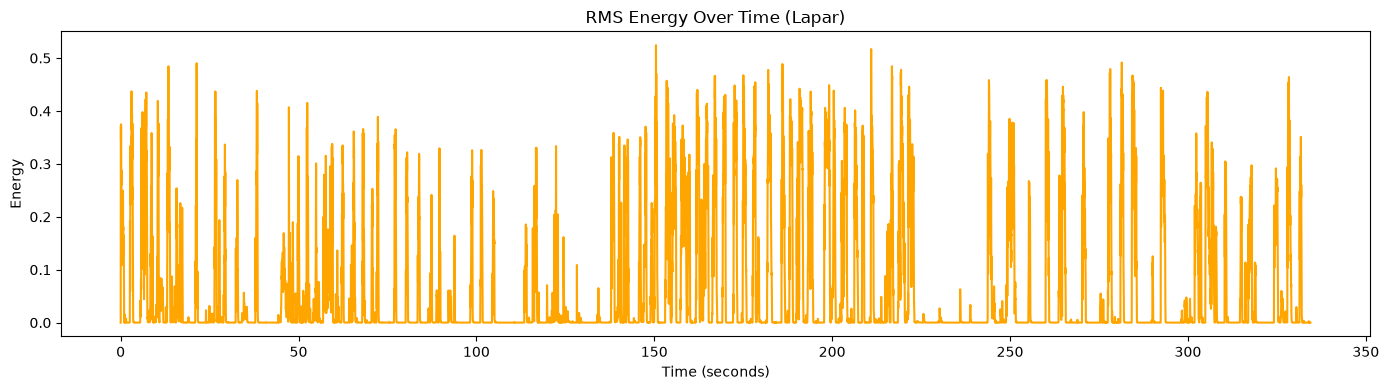

In [ ]:
key_lapar, y_lapar_single = list(lapar_audio_data.items())[0]
sr_lapar_single = lapar_sample_rates[key_lapar]

rms_l = librosa.feature.rms(
    y=y_lapar_single,
    frame_length=frame_length,
    hop_length=hop_length
)[0]

times_l = librosa.frames_to_time(range(len(rms_l)), sr=sr_lapar_single, hop_length=hop_length)

plt.figure(figsize=(14,4))
plt.plot(times_l, rms_l, color='orange')
plt.title("RMS Energy Over Time (Lapar)")
plt.xlabel("Time (seconds)")
plt.ylabel("Energy")
plt.tight_layout()
plt.show()


## 7. Analisis Zero Crossing Rate (ZCR)
ZCR membantu dalam mendeteksi seberapa sering sinyal audio melewati angka 0. Suara bising/tajam biasanya memiliki nilai ZCR yang lebih tinggi.


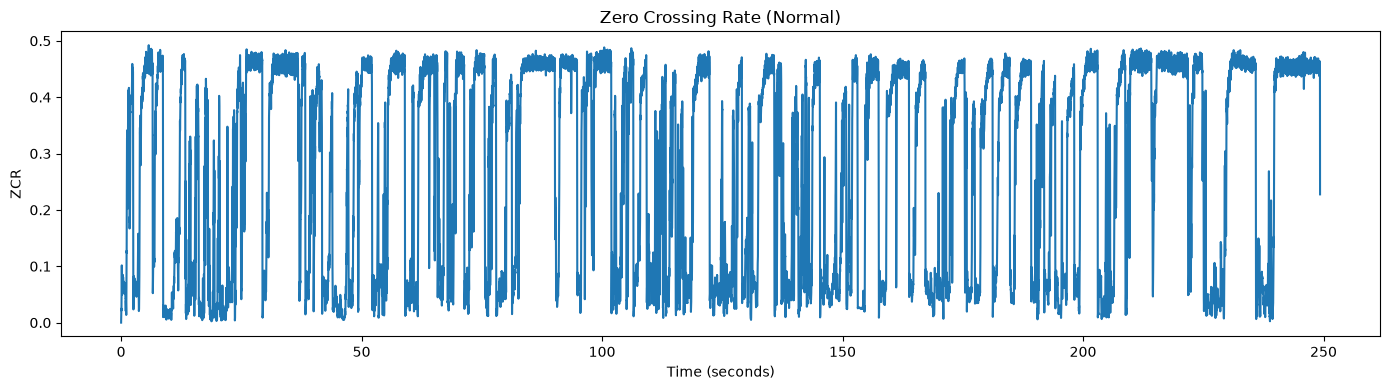

In [ ]:
zcr = librosa.feature.zero_crossing_rate(y_normal)[0]
times_zcr = librosa.frames_to_time(range(len(zcr)), sr=sr_normal, hop_length=512)

plt.figure(figsize=(14,4))
plt.plot(times_zcr, zcr)
plt.title("Zero Crossing Rate (Normal)")
plt.xlabel("Time (seconds)")
plt.ylabel("ZCR")
plt.tight_layout()
plt.show()


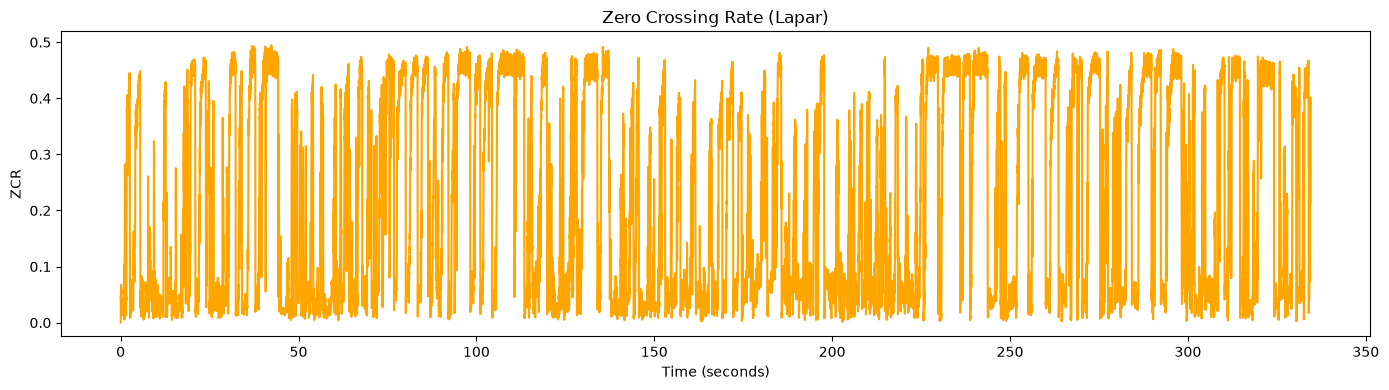

In [ ]:
zcr_l = librosa.feature.zero_crossing_rate(y_lapar_single)[0]
times_zcr_l = librosa.frames_to_time(range(len(zcr_l)), sr=sr_lapar_single, hop_length=512)

plt.figure(figsize=(14,4))
plt.plot(times_zcr_l, zcr_l, color='orange')
plt.title("Zero Crossing Rate (Lapar)")
plt.xlabel("Time (seconds)")
plt.ylabel("ZCR")
plt.tight_layout()
plt.show()
